In [17]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import spacy
from wordcloud import WordCloud

# Add the parent directory to sys.path so src can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import src.utils as utils

In [18]:
file_path = r"..\data\results\ciencia_chunks.xlsx"
fragmentos_ciencia = pd.read_excel(file_path, engine='openpyxl')

file_path2 = r"..\data\processed\corpus_cleaned.xlsx"
corpus_limpio = pd.read_excel(file_path2, engine='openpyxl')

chunks_df = pd.read_parquet(r"..\data\processed\chunks.parquet")

In [19]:
# Unir metadatos del corpus
fragmentos_ciencia = fragmentos_ciencia.merge(
    corpus_limpio[["ID", "Autor", "Diario", "Fecha", "Título"]],
    left_on="id_doc",
    right_on="ID",
    how="left"
)

fragmentos_ciencia.drop(columns=["ID"], inplace=True)

In [22]:
fragmentos_ciencia

,chunk_id,id_doc,texto_chunk,Ciencias_ambientales_ingenieria,Ciencias_espacio,Ciencias_fisicas,Ciencias_Geografia_oceanografia,Ciencias_medicas,Ciencias_metereologia,Ciencias_naturales,...,Ciencia_enfoque_cientifico,Ciencia_hidrologia,Ciencia_matematicas_estadistica,Ciencia_patologia,Ciencia_recursos_naturales,categorias_detectadas,Autor,Diario,Fecha,Título
0,1,2,sin que ello aminore una sensación interior de...,0.381569,0.436646,0.438092,0.443139,0.424599,0.400453,0.431749,...,0.356943,0.389384,0.437434,0.475389,0.389163,"[('Ciencia_patologia', 0.4753885567188263)]",Eduardo Barajas Sandoval,El Espectador,2018-01-01,Macedonia de Norte
1,2,2,Una de esas partes del mundo en las que se dem...,0.409443,0.453016,0.439897,0.492942,0.420311,0.422557,0.473182,...,0.395951,0.414943,0.463356,0.432422,0.404940,"[('Ciencias_Geografia_oceanografia', 0.4929419...",Eduardo Barajas Sandoval,El Espectador,2018-01-01,Macedonia de Norte
2,5,2,la conclusión de una supuesta naturaleza eslav...,0.436410,0.436850,0.442821,0.430071,0.437403,0.401465,0.482916,...,0.414646,0.414762,0.456277,0.428941,0.387112,"[('Ciencias_naturales', 0.4829162657260895)]",Eduardo Barajas Sandoval,El Espectador,2018-01-01,Macedonia de Norte
3,2,4,"máquinas, y exigir tiempos para el descanso y ...",0.436326,0.463700,0.473826,0.418863,0.452321,0.423207,0.464194,...,0.405467,0.424928,0.470929,0.446787,0.408819,"[('Ciencias_fisicas', 0.47382622957229614), ('...",Reinaldo Spitaletta,El Espectador,2018-01-01,"Tiempo sagrado, tiempo profano"
4,1,7,pacientes y familiares y se pasan por la faja ...,0.386182,0.378725,0.407948,0.386569,0.445371,0.380922,0.438412,...,0.375680,0.389403,0.408311,0.490057,0.354221,"[('Ciencia_patologia', 0.49005743861198425)]",Beatriz Vanegas Athías,El Espectador,2018-01-01,2017 (I)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,3,13676,indicador claro de pensamiento es la imitación...,0.424993,0.413263,0.438549,0.380797,0.427578,0.410939,0.441292,...,0.484869,0.417249,0.478297,0.440545,0.382960,"[('Ciencia_enfoque_cientifico', 0.484868794679...",Julián de Zubiría Samper,Semana,2019-06-03,¿Piensan los animales?
7263,5,13676,segundo nuevamente a las condiciones del medio...,0.411103,0.370712,0.380938,0.427004,0.353794,0.401876,0.501847,...,0.391338,0.396796,0.396868,0.364834,0.429692,"[('Ciencias_naturales', 0.5018470287322998)]",Julián de Zubiría Samper,Semana,2019-06-03,¿Piensan los animales?
7264,6,13676,el ave decide enterrar las semillas en un espa...,0.425895,0.431100,0.406602,0.411929,0.397041,0.444183,0.475786,...,0.376744,0.437717,0.413619,0.389658,0.434147,"[('Ciencias_naturales', 0.47578564286231995)]",Julián de Zubiría Samper,Semana,2019-06-03,¿Piensan los animales?
7265,8,13676,capacidad de predecir un evento futuro. Por lo...,0.443493,0.391822,0.389754,0.347909,0.398877,0.376082,0.483115,...,0.395771,0.373874,0.394229,0.382154,0.440733,"[('Ciencias_naturales', 0.48311546444892883)]",Julián de Zubiría Samper,Semana,2019-06-03,¿Piensan los animales?


In [20]:
nlp = spacy.load("es_core_news_sm")
# Stopwords en español
STOP_WORDS = nlp.Defaults.stop_words

# Nube de palabras general

In [23]:
texto = " ".join(corpus_limpio["Texto_limpio"].tolist())
texto = texto.lower()

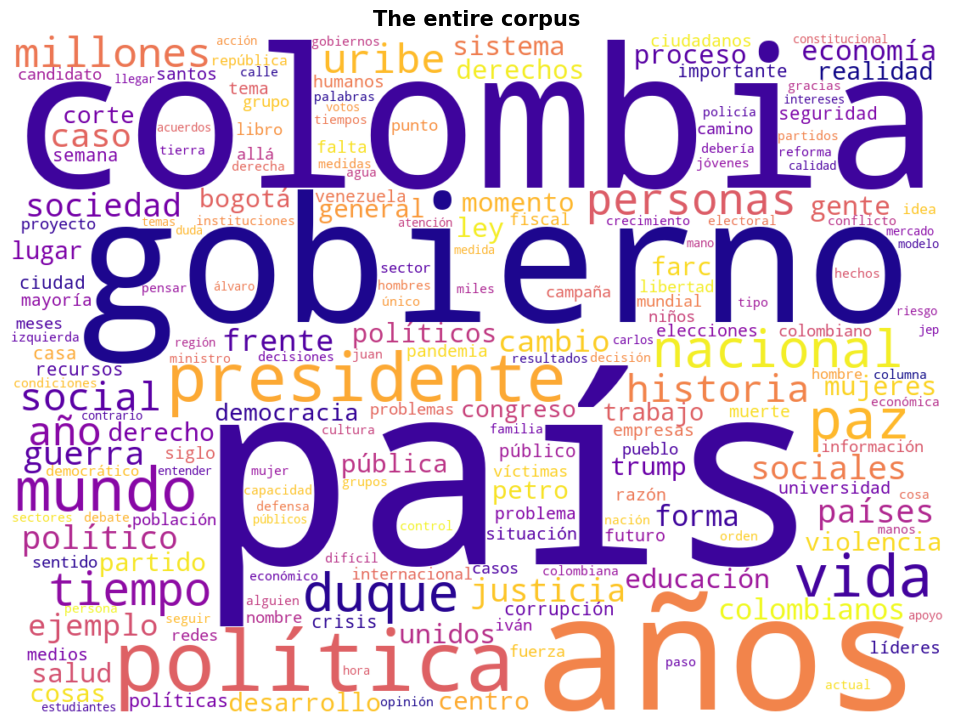

In [24]:
wc = WordCloud(
        width=1100, height=800,
        background_color='white',
        max_words=200,
        stopwords=STOP_WORDS,
        prefer_horizontal=1.0,  # Todas horizontales
        relative_scaling=0.9,   
        collocations=False,
        random_state=42,
        min_font_size=10,
        #max_font_size=150,
        colormap='plasma',
        normalize_plurals = False
    ).generate(texto)

 # Crear la visualización
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title("The entire corpus", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.axis('off')
plt.savefig("../reports/articulo_revista/figures/nube_general.png", dpi=300)
plt.show()

In [25]:
texto_ciencia = " ".join(fragmentos_ciencia["texto_chunk"].tolist())
texto_ciencia = texto_ciencia.lower()

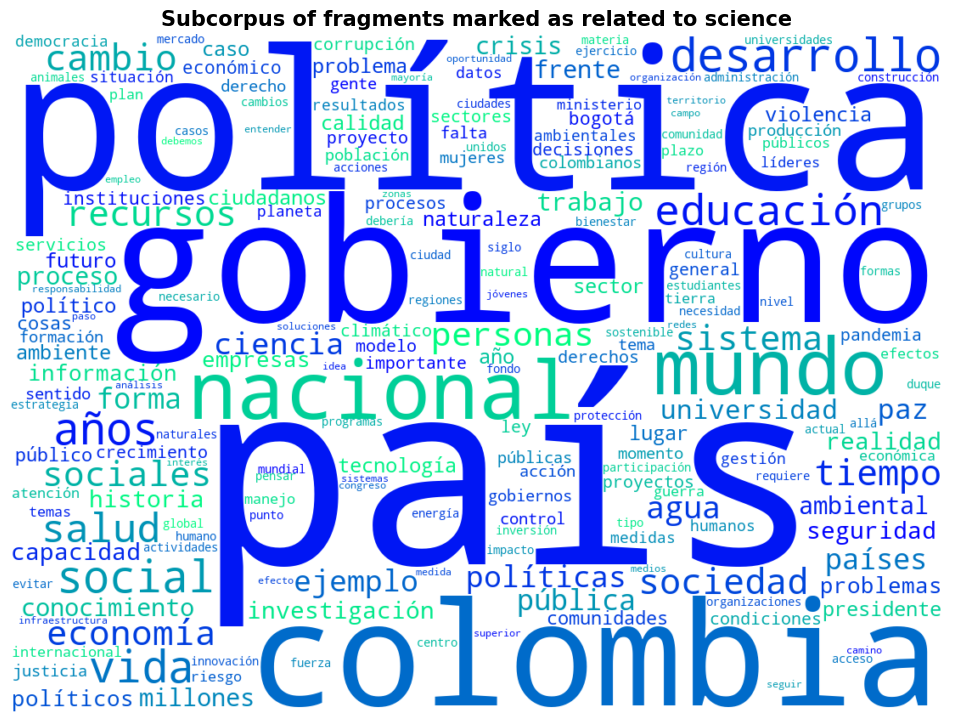

In [26]:
wc_ciencia = WordCloud(
        width=1100, height=800,
        background_color='white',
        max_words=200,
        stopwords=STOP_WORDS,
        prefer_horizontal=1.0,  # Todas horizontales
        relative_scaling=0.9,   
        collocations=False,
        random_state=42,
        min_font_size=10,
        #max_font_size=200,
        colormap='winter',
        normalize_plurals = False
    ).generate(texto_ciencia)

 # Crear la visualización
plt.figure(figsize=(10, 8))
plt.imshow(wc_ciencia, interpolation='bilinear')
plt.title("Subcorpus of fragments marked as related to science", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.axis('off')
plt.savefig("../reports/articulo_revista/figures/nube_ciencia.png", dpi=300)
plt.show()